# B141 Data Mining — Market Basket Analysis (The Bread Basket)
Technique: Frequent Itemset Mining (Apriori) + Association Rules.
Dataset: The Bread Basket — real bakery transactions (~9,500 transactions, 94 items).
Source: https://www.kaggle.com/datasets/mittalvasu95/the-bread-basket

In [1]:
!pip install mlxtend -q

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


## Step 1 — Load the data
The dataset is uploaded as a zip. We unzip it and load the CSV.
Each row = one item in one transaction

In [3]:
import zipfile, glob
import pandas as pd

# unzip whatever .zip was uploaded
for z in glob.glob("*.zip"):
    with zipfile.ZipFile(z) as zf:
        zf.extractall(".")

# find the bread basket csv
csv_path = next(f for f in glob.glob("**/*.csv", recursive=True)
                if "bread" in f.lower() or "basket" in f.lower())
print("Using file:", csv_path)

df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)
df.head()

Using file: bread basket.csv
Raw shape: (20507, 5)


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


## Step 2 — Preprocessing
- Standardise item text so the same product isn't split in two.
- Remove placeholder 'None' rows (not real products).
- Drop duplicate (Transaction, Item) rows: association-rule mining treats each
  basket as a SET of items, so we only keep whether an item appears, not how often.
- Parse the timestamp for time-based analysis.

In [4]:
df["Item"] = df["Item"].str.strip().str.title()
df = df[df["Item"].str.lower() != "none"]

before = len(df)
df = df.drop_duplicates(subset=["Transaction", "Item"])
print("Dropped", before - len(df), "duplicate rows")

df["date_time"] = pd.to_datetime(df["date_time"], format="%d-%m-%Y %H:%M", errors="coerce")
df["hour"] = df["date_time"].dt.hour

print("Clean:", len(df), "rows |",
      df["Transaction"].nunique(), "transactions |",
      df["Item"].nunique(), "items")

Dropped 1620 duplicate rows
Clean: 18887 rows | 9465 transactions | 94 items


## Step 3 — Exploratory Data Analysis
Top items, transactions by hour, and average basket size.

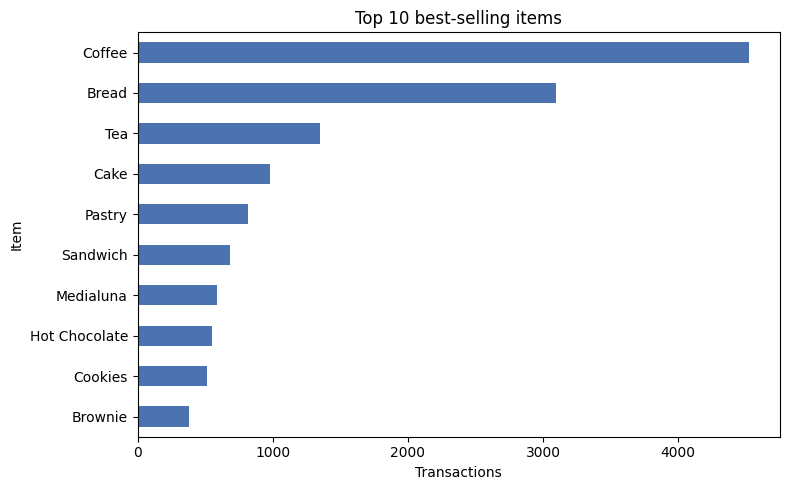

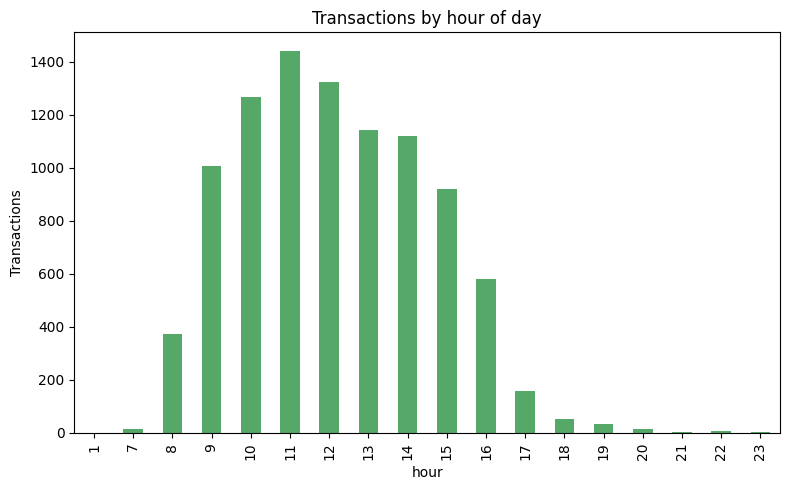

Average basket size: 2.00 items


In [5]:
import matplotlib.pyplot as plt

top_items = df["Item"].value_counts().head(10)
top_items.sort_values().plot(kind="barh", figsize=(8,5), color="#4C72B0")
plt.title("Top 10 best-selling items"); plt.xlabel("Transactions")
plt.tight_layout(); plt.show()

df.groupby("hour")["Transaction"].nunique().plot(kind="bar", figsize=(8,5), color="#55A868")
plt.title("Transactions by hour of day"); plt.ylabel("Transactions")
plt.tight_layout(); plt.show()

basket_sizes = df.groupby("Transaction")["Item"].nunique()
print("Average basket size: %.2f items" % basket_sizes.mean())

## Step 4 — Build the list of transactions (baskets)
We group all items bought in the same Transaction into one set of items.
This matches the "Market-Basket transactions" model from the lecture (slide 5):
a set of baskets, each a small set of items.

In [6]:
# each transaction becomes a set of items (a "basket")
transactions = df.groupby("Transaction")["Item"].apply(set).tolist()
print("Number of baskets:", len(transactions))
print("Example basket:", transactions[2])

Number of baskets: 9465
Example basket: {'Jam', 'Hot Chocolate', 'Cookies'}


## Step 5 — Apriori from the lecture pseudo-code
We implement Apriori directly from the slides

In [7]:
from itertools import combinations

minsup = 0.01
N = len(transactions)
min_count = minsup * N   # support threshold as a raw count

def get_support_counts(candidates, transactions):
    """Scan the database once and count how many baskets contain each candidate
    (this is the 'increment the count of all candidates contained in t' step, slide 23)."""
    counts = {c: 0 for c in candidates}
    for t in transactions:
        for c in candidates:
            if c.issubset(t):
                counts[c] += 1
    return counts

# --- L1: frequent 1-itemsets ---
item_counts = {}
for t in transactions:
    for item in t:
        item_counts[frozenset([item])] = item_counts.get(frozenset([item]), 0) + 1

L = {c for c, cnt in item_counts.items() if cnt >= min_count}
all_frequent = {c: item_counts[c] for c in L}     # keep support counts of everything frequent
print("Frequent 1-itemsets:", len(L))

# --- iterate k = 2, 3, ... ---
k = 2
while L:
    # CANDIDATE GENERATION: join two (k-1)-itemsets that share their first k-2 items (slide 24-31)
    L_list = [sorted(s) for s in L]
    candidates = set()
    for i in range(len(L_list)):
        for j in range(i + 1, len(L_list)):
            a, b = L_list[i], L_list[j]
            if a[:k-2] == b[:k-2]:                # share first k-2 items
                candidate = frozenset(a) | frozenset(b)
                if len(candidate) == k:
                    # PRUNE: every (k-1)-subset must be frequent (Apriori principle, slide 33)
                    if all(frozenset(sub) in L for sub in combinations(candidate, k-1)):
                        candidates.add(candidate)

    if not candidates:
        break

    # COUNT support by scanning the data
    counts = get_support_counts(candidates, transactions)
    L = {c for c, cnt in counts.items() if cnt >= min_count}
    all_frequent.update({c: counts[c] for c in L})
    print(f"Frequent {k}-itemsets:", len(L))
    k += 1

print("Total frequent itemsets:", len(all_frequent))

Frequent 1-itemsets: 30
Frequent 2-itemsets: 28
Frequent 3-itemsets: 3
Total frequent itemsets: 61


## Step 6 — Association rules: confidence & lift
From each frequent itemset we generate rules

In [8]:
from itertools import combinations

N = len(transactions)
min_conf = 0.2

def support(itemset):
    # support = fraction of transactions containing the itemset
    return all_frequent[frozenset(itemset)] / N

rules = []
for itemset in all_frequent:
    if len(itemset) < 2:
        continue  # need at least 2 items to form a rule
    items = list(itemset)
    # try every non-empty proper subset as the antecedent X
    for r in range(1, len(items)):
        for X in combinations(items, r):
            X = frozenset(X)
            Y = itemset - X
            conf = support(itemset) / support(X)          # P(Y|X)
            lift = conf / support(Y)                        # confidence / support(Y)
            if conf >= min_conf and lift > 1:
                rules.append({
                    "antecedent": ", ".join(sorted(X)),
                    "consequent": ", ".join(sorted(Y)),
                    "support": round(support(itemset), 3),
                    "confidence": round(conf, 3),
                    "lift": round(lift, 3),
                })

rules_df = pd.DataFrame(rules).sort_values("lift", ascending=False).reset_index(drop=True)
print("Interesting rules found:", len(rules_df))
rules_df.head(10)

Interesting rules found: 17


,antecedent,consequent,support,confidence,lift
0,"Coffee, Tea",Cake,0.010,0.201,1.938
1,Cake,Tea,0.024,0.229,1.605
2,Toast,Coffee,0.024,0.704,1.472
3,Sandwich,Tea,0.014,0.200,1.402
4,Spanish Brunch,Coffee,0.011,0.599,1.252
5,Medialuna,Coffee,0.035,0.569,1.190
6,Pastry,Coffee,0.048,0.552,1.154
7,Alfajores,Coffee,0.020,0.541,1.130
8,Juice,Coffee,0.021,0.534,1.117
9,Sandwich,Coffee,0.038,0.532,1.113


## Step 6b — Visualising the rules
Support vs confidence, coloured by lift. Points high on both axes with bright
colour (high lift) are the genuinely strong, actionable rules.

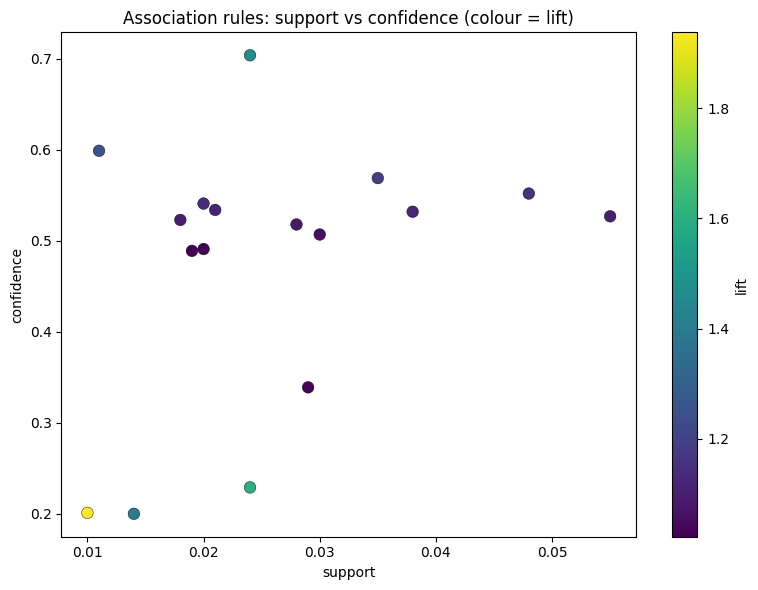

In [9]:
plt.figure(figsize=(8,6))
sc = plt.scatter(rules_df["support"], rules_df["confidence"],
                 c=rules_df["lift"], cmap="viridis", s=70, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, label="lift")
plt.xlabel("support"); plt.ylabel("confidence")
plt.title("Association rules: support vs confidence (colour = lift)")
plt.tight_layout(); plt.show()

## Step 7 — Segment comparison (non-trivial insight)


In [10]:
def mine_rules(frame, minsup=0.01, min_conf=0.2):
    txns = frame.groupby("Transaction")["Item"].apply(set).tolist()
    n = len(txns)
    mc = minsup * n

    # frequent 1-itemsets
    counts = {}
    for t in txns:
        for it in t:
            counts[frozenset([it])] = counts.get(frozenset([it]), 0) + 1
    L = {c for c, v in counts.items() if v >= mc}
    freq = {c: counts[c] for c in L}

    # higher orders
    k = 2
    while L:
        Ll = [sorted(s) for s in L]
        cand = set()
        for i in range(len(Ll)):
            for j in range(i+1, len(Ll)):
                a, b = Ll[i], Ll[j]
                if a[:k-2] == b[:k-2]:
                    c = frozenset(a) | frozenset(b)
                    if len(c) == k and all(frozenset(s) in L for s in combinations(c, k-1)):
                        cand.add(c)
        if not cand: break
        cc = {c: 0 for c in cand}
        for t in txns:
            for c in cand:
                if c.issubset(t): cc[c] += 1
        L = {c for c, v in cc.items() if v >= mc}
        freq.update({c: cc[c] for c in L})
        k += 1

    # rules
    out = []
    for s in freq:
        if len(s) < 2: continue
        items = list(s)
        for r in range(1, len(items)):
            for X in combinations(items, r):
                X = frozenset(X); Y = s - X
                conf = freq[s]/n / (freq[X]/n)
                lift = conf / (freq[Y]/n)
                if conf >= min_conf and lift > 1:
                    out.append({"antecedent": ", ".join(sorted(X)),
                                "consequent": ", ".join(sorted(Y)),
                                "confidence": round(conf,3), "lift": round(lift,3)})
    return pd.DataFrame(out).sort_values("lift", ascending=False).head(5).reset_index(drop=True)

for seg in ["weekend", "weekday"]:
    print(f"--- Top rules ({seg}) ---")
    print(mine_rules(df[df["weekday_weekend"] == seg]), "\n")

--- Top rules (weekend) ---
       antecedent consequent  confidence   lift
0     Coffee, Tea       Cake       0.223  1.878
1   Hot Chocolate       Cake       0.208  1.750
2           Scone        Tea       0.217  1.666
3            Cake        Tea       0.216  1.658
4  Spanish Brunch     Coffee       0.703  1.512 

--- Top rules (weekday) ---
  antecedent consequent  confidence   lift
0       Soup        Tea       0.270  1.804
1       Cake        Tea       0.238  1.591
2      Toast     Coffee       0.712  1.466
3   Sandwich        Tea       0.216  1.446
4    Cookies        Tea       0.202  1.353 

